In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

df = pd.DataFrame(X, columns=housing.feature_names)
df["Target"] = y

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

df.head(10)

Feature matrix shape: (20640, 8)
Target shape: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


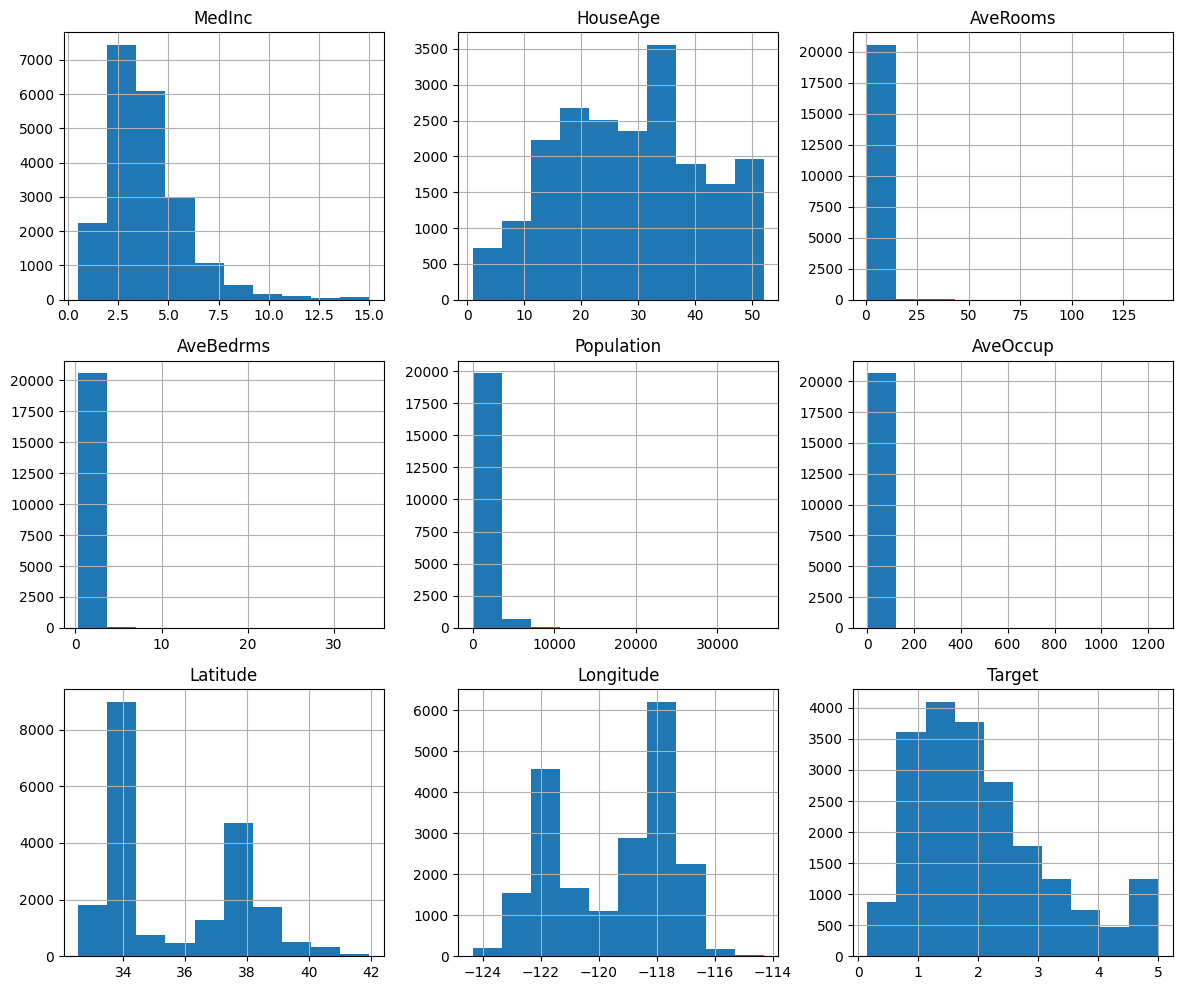

In [4]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

The histograms show the distribution of each feature. Some features appear skewed, indicating the presence of outliers.

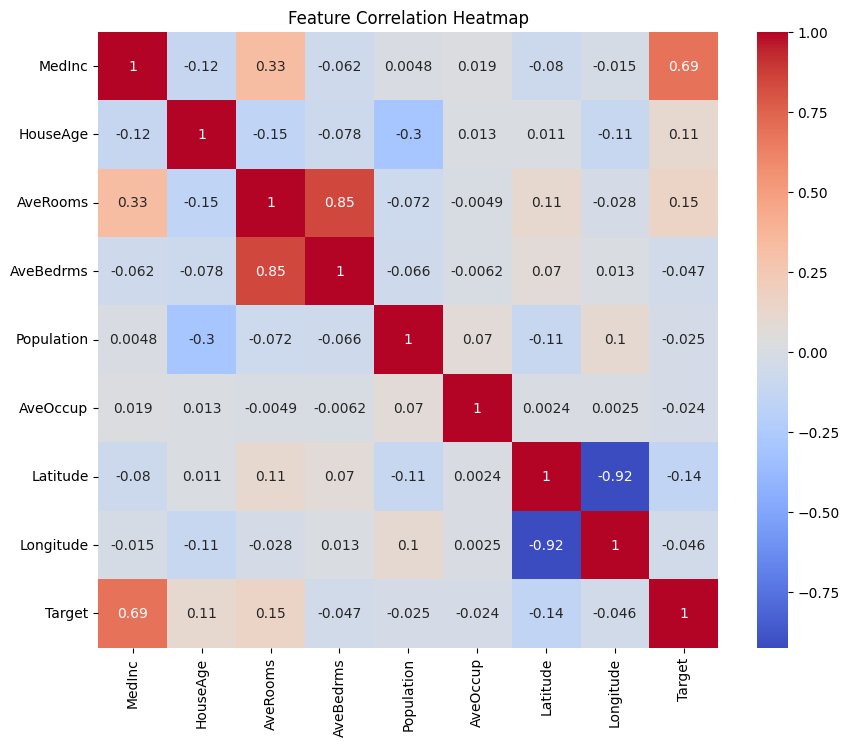

In [5]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

The correlation heatmap shows relationships between features. Median income has the strongest positive correlation with house value.

<function matplotlib.pyplot.show(close=None, block=None)>

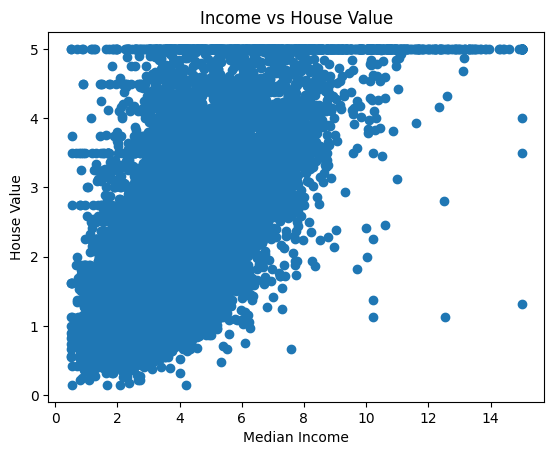

In [6]:
plt.scatter(df["MedInc"], df["Target"])
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Income vs House Value")
plt.show



This plot shows that house value increases as median income increases, indicating a strong relationship.

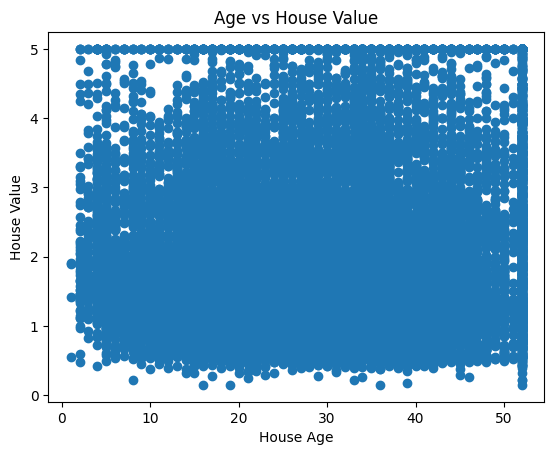

In [7]:
plt.scatter(df["HouseAge"], df["Target"])
plt.xlabel("House Age")
plt.ylabel("House Value")
plt.title("Age vs House Value")
plt.show()

The relationship between house age and house value is weaker compared to income.

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (14448, 8)
Validation: (3096, 8)
Test: (3096, 8)


The dataset is divided into training, validation, and test sets in a 70/15/15 ratio.

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

StandardScaler is used to normalize the features. It is fitted only on the training data to avoid data leakage

In [10]:
model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(16, activation="relu"))
model.add(Dense(1))

C:\Users\jyots\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 128 (512.00 B)

The neural network consists of three hidden layers with ReLU activation, allowing it to learn complex patterns.

In [12]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

Mean Squared Error (MSE) is used as the loss function because it penalizes larger errors more strongly. Mean Absolute Error (MAE) is used as an additional evaluation metric.

In [13]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_regression_model.keras",
    save_best_only=True
)

In [14]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/40
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.9734 - mae: 0.7025 - val_loss: 0.4928 - val_mae: 0.4786
Epoch 2/40
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5388 - mae: 0.5279 - val_loss: 0.4851 - val_mae: 0.4749
Epoch 3/40
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4628 - mae: 0.4908 - val_loss: 0.4246 - val_mae: 0.4504
Epoch 4/40
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4464 - mae: 0.4792 - val_loss: 0.4870 - val_mae: 0.4794
Epoch 5/40
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4202 - mae: 0.4623 - val_loss: 0.4603 - val_mae: 0.4671
Epoch 6/40
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4074 - mae: 0.4556 - val_loss: 0.3871 - val_mae: 0.4265
Epoch 7/40
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3949 - mae: 0.4456 - val_loss: 0.4112 - val_mae: 0.4332
Epoch 8/40
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3794 - mae: 0.4367 - val_loss: 0.3644 - val_mae: 0.4047
Epoch 9/40
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - lo

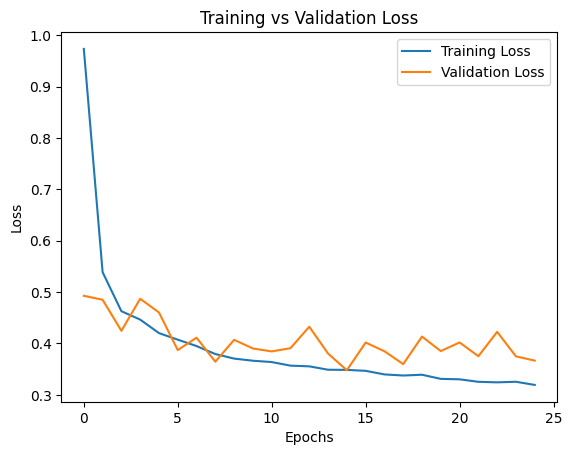

In [15]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

The training and validation loss decrease over epochs, indicating that the model is learning effectively. The small gap between the curves suggests that the model generalizes well without significant overfitting.

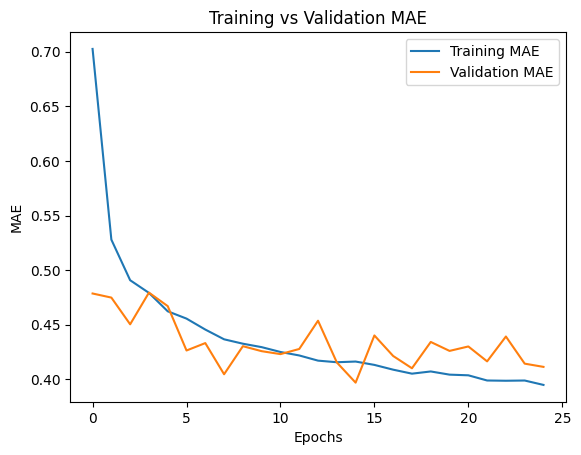

In [16]:
plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()
plt.show()

The Mean Absolute Error decreases for both training and validation sets, showing that the model's prediction accuracy improves over time.

In [17]:
test_loss, test_mae = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test MAE:", test_mae)

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 879us/step - loss: 0.3196 - mae: 0.3861
Test Loss: 0.3195645213127136
Test MAE: 0.3860546946525574


The test results show that the model performs well on unseen data, indicating good generalization.

In [18]:
y_pred = model.predict(X_test)

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step


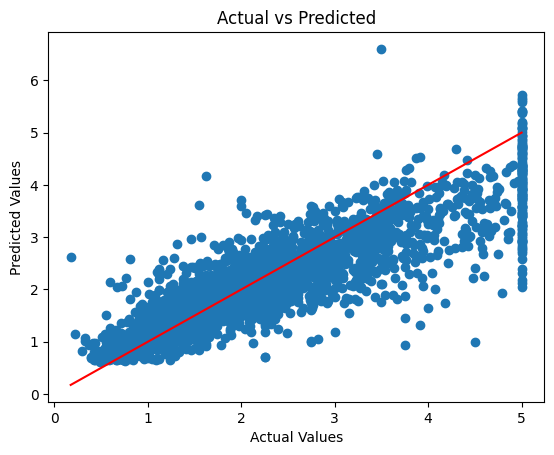

In [19]:
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

Most points lie close to the diagonal line, indicating that the predicted values are close to the actual values.

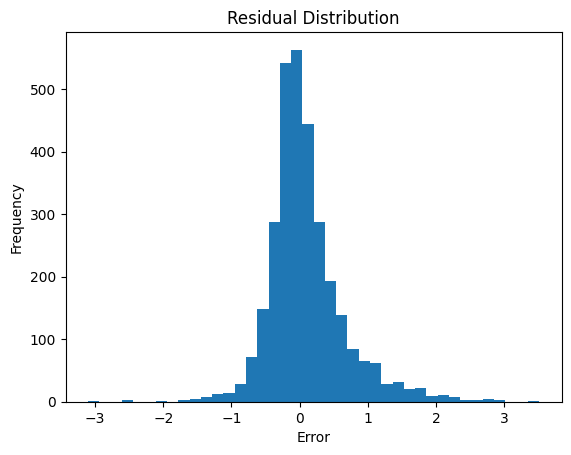

In [20]:
errors = y_test - y_pred.flatten()

plt.hist(errors, bins=40)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

The residuals are centered around zero, indicating that the model errors are reasonably distributed without strong bias.

In [21]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.38605465130397515
RMSE: 0.5653003409964613
R2 Score: 0.758328702245491


The model achieves reasonable performance with acceptable error values. Further improvements can be made using hyperparameter tuning, feature engineering, or deeper architectures.